In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
filepath="Crime_Data_from_2020_to_Present.csv"
df= pd.read_csv(filepath) #this is the rule of Industry 4.0 -> the file path should be stored inside a variable, and then called in the next line


In [3]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,101.0,STREET,AA,Adult Arrest,510.0,998.0,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),IC,Invest Cont,330.0,998.0,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,1,480,BIKE - STOLEN,...,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,480.0,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,405.0,CLOTHING STORE,IC,Invest Cont,343.0,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,101.0,STREET,IC,Invest Cont,510.0,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [4]:
print("Shape(rows,cols):",df.shape) #display with a message -> Industry 4.0 technique
print("Columns:",df.columns.to_list()) #the 'shape' prints the total number of rows along with total number of columns

Shape(rows,cols): (1005198, 24)
Columns: ['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'LOCATION', 'Cross Street', 'LAT', 'LON']


In [5]:
missing= df.isnull().sum()
missing

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA                 0
AREA NAME            0
Rpt Dist No          0
Part 1-2             0
Crm Cd               0
Crm Cd Desc          0
Mocodes         151760
Vict Age             0
Vict Sex        144782
Vict Descent    144794
Premis Cd           16
Premis Desc        588
Status               1
Status Desc          0
Crm Cd 1            11
Crm Cd 2        936039
LOCATION             0
Cross Street    850955
LAT                  0
LON                  0
dtype: int64

In [6]:
miss_perc=(missing/len(df)*100).round(2)
miss_perc

DR_NO            0.00
Date Rptd        0.00
DATE OCC         0.00
TIME OCC         0.00
AREA             0.00
AREA NAME        0.00
Rpt Dist No      0.00
Part 1-2         0.00
Crm Cd           0.00
Crm Cd Desc      0.00
Mocodes         15.10
Vict Age         0.00
Vict Sex        14.40
Vict Descent    14.40
Premis Cd        0.00
Premis Desc      0.06
Status           0.00
Status Desc      0.00
Crm Cd 1         0.00
Crm Cd 2        93.12
LOCATION         0.00
Cross Street    84.66
LAT              0.00
LON              0.00
dtype: float64

In [7]:
# df[df.duplicated()].shape[0]
print("Duplicate records",df[df.duplicated()].shape[0])


Duplicate records 0


In [8]:
# duplicate key checking for the primary key 
df["DR_NO"].duplicated().sum()

# df["DR_NO"].is_unique

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 24 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   DR_NO         1005198 non-null  int64  
 1   Date Rptd     1005198 non-null  object 
 2   DATE OCC      1005198 non-null  object 
 3   TIME OCC      1005198 non-null  object 
 4   AREA          1005198 non-null  int64  
 5   AREA NAME     1005198 non-null  object 
 6   Rpt Dist No   1005198 non-null  int64  
 7   Part 1-2      1005198 non-null  int64  
 8   Crm Cd        1005198 non-null  int64  
 9   Crm Cd Desc   1005198 non-null  object 
 10  Mocodes       853438 non-null   object 
 11  Vict Age      1005198 non-null  int64  
 12  Vict Sex      860416 non-null   object 
 13  Vict Descent  860404 non-null   object 
 14  Premis Cd     1005182 non-null  float64
 15  Premis Desc   1004610 non-null  object 
 16  Status        1005197 non-null  object 
 17  Status Desc   1005198 non-n

In [10]:
# df= df.drop_duplicates()
df[df.duplicated(keep=False)]

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,LOCATION,Cross Street,LAT,LON


In [11]:
# Saving a copy of the file 
df_clean= df.copy()
df_clean.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,101.0,STREET,AA,Adult Arrest,510.0,998.0,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),IC,Invest Cont,330.0,998.0,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,1,480,BIKE - STOLEN,...,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,480.0,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,405.0,CLOTHING STORE,IC,Invest Cont,343.0,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,101.0,STREET,IC,Invest Cont,510.0,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [12]:
df = df.dropna(thresh=len(df)*0.5, axis=1)

In [13]:
print(df.isnull().sum())

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA                 0
AREA NAME            0
Rpt Dist No          0
Part 1-2             0
Crm Cd               0
Crm Cd Desc          0
Mocodes         151760
Vict Age             0
Vict Sex        144782
Vict Descent    144794
Premis Cd           16
Premis Desc        588
Status               1
Status Desc          0
Crm Cd 1            11
LOCATION             0
LAT                  0
LON                  0
dtype: int64


In [14]:
df.head()


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,M,O,101.0,STREET,AA,Adult Arrest,510.0,1900 S LONGWOOD AV,34.0375,-118.3506
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),IC,Invest Cont,330.0,1000 S FLOWER ST,34.0444,-118.2628
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,1,480,BIKE - STOLEN,...,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,480.0,1400 W 37TH ST,34.0210,-118.3002
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,M,O,405.0,CLOTHING STORE,IC,Invest Cont,343.0,14000 RIVERSIDE DR,34.1576,-118.4387
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,NaN,NaN,101.0,STREET,IC,Invest Cont,510.0,200 E AVENUE 28,34.0820,-118.2130


In [15]:
df1= df.drop(['Part 1-2','Mocodes','Vict Descent','Premis Cd','Status','Crm Cd 1','Vict Descent','LOCATION','LAT','LON'],axis=1)
df1

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,0,M,STREET,Adult Arrest
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,0,NaN,STREET,Invest Cont
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025,2/21/2025,15:30,3,Southwest,358,510,VEHICLE - STOLEN,0,NaN,STREET,Invest Cont
1005194,250304203,2/20/2025,2/13/2025,21:00,3,Southwest,325,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",0,NaN,PARKING LOT,Invest Cont
1005195,250504051,1/14/2025,1/14/2025,12:50,5,Harbor,509,210,ROBBERY,15,F,HIGH SCHOOL,Invest Cont
1005196,251604136,2/27/2025,2/27/2025,15:50,16,Foothill,1664,510,VEHICLE - STOLEN,0,NaN,STREET,Adult Arrest


In [16]:
df1.head()


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,0,M,STREET,Adult Arrest
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,0,NaN,STREET,Invest Cont


In [17]:
df1.isnull().sum()

DR_NO               0
Date Rptd           0
DATE OCC            0
TIME OCC            0
AREA                0
AREA NAME           0
Rpt Dist No         0
Crm Cd              0
Crm Cd Desc         0
Vict Age            0
Vict Sex       144782
Premis Desc       588
Status Desc         0
dtype: int64

In [18]:
mn= df1[df1['Vict Age']!=0]['Vict Age'].mean()
mn

39.49712905720277

In [19]:
df1['Vict Age']= df1['Vict Age'].replace(0,mn)
df1

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,39.497129,M,STREET,Adult Arrest
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47.000000,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19.000000,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19.000000,M,CLOTHING STORE,Invest Cont
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,39.497129,NaN,STREET,Invest Cont
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025,2/21/2025,15:30,3,Southwest,358,510,VEHICLE - STOLEN,39.497129,NaN,STREET,Invest Cont
1005194,250304203,2/20/2025,2/13/2025,21:00,3,Southwest,325,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",39.497129,NaN,PARKING LOT,Invest Cont
1005195,250504051,1/14/2025,1/14/2025,12:50,5,Harbor,509,210,ROBBERY,15.000000,F,HIGH SCHOOL,Invest Cont
1005196,251604136,2/27/2025,2/27/2025,15:50,16,Foothill,1664,510,VEHICLE - STOLEN,39.497129,NaN,STREET,Adult Arrest


In [20]:
df1['Vict Age']= df1['Vict Age'].astype(int)
df1

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,39,NaN,STREET,Invest Cont
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025,2/21/2025,15:30,3,Southwest,358,510,VEHICLE - STOLEN,39,NaN,STREET,Invest Cont
1005194,250304203,2/20/2025,2/13/2025,21:00,3,Southwest,325,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",39,NaN,PARKING LOT,Invest Cont
1005195,250504051,1/14/2025,1/14/2025,12:50,5,Harbor,509,210,ROBBERY,15,F,HIGH SCHOOL,Invest Cont
1005196,251604136,2/27/2025,2/27/2025,15:50,16,Foothill,1664,510,VEHICLE - STOLEN,39,NaN,STREET,Adult Arrest


In [21]:
df1['Vict Sex'] = df1['Vict Sex'].fillna(df1['Vict Sex'].mode()[0]) #the '0' will replace the blank values with the most used value
df1

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025,2/21/2025,15:30,3,Southwest,358,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont
1005194,250304203,2/20/2025,2/13/2025,21:00,3,Southwest,325,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",39,M,PARKING LOT,Invest Cont
1005195,250504051,1/14/2025,1/14/2025,12:50,5,Harbor,509,210,ROBBERY,15,F,HIGH SCHOOL,Invest Cont
1005196,251604136,2/27/2025,2/27/2025,15:50,16,Foothill,1664,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest


In [22]:
df1.isnull().sum()

DR_NO            0
Date Rptd        0
DATE OCC         0
TIME OCC         0
AREA             0
AREA NAME        0
Rpt Dist No      0
Crm Cd           0
Crm Cd Desc      0
Vict Age         0
Vict Sex         0
Premis Desc    588
Status Desc      0
dtype: int64

In [23]:
df1['Premis Desc'] = df['Premis Desc'].fillna(df['Premis Desc'].mode()[0])
df1

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025,2/21/2025,15:30,3,Southwest,358,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont
1005194,250304203,2/20/2025,2/13/2025,21:00,3,Southwest,325,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",39,M,PARKING LOT,Invest Cont
1005195,250504051,1/14/2025,1/14/2025,12:50,5,Harbor,509,210,ROBBERY,15,F,HIGH SCHOOL,Invest Cont
1005196,251604136,2/27/2025,2/27/2025,15:50,16,Foothill,1664,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest


In [24]:
df1.isnull().sum()

DR_NO          0
Date Rptd      0
DATE OCC       0
TIME OCC       0
AREA           0
AREA NAME      0
Rpt Dist No    0
Crm Cd         0
Crm Cd Desc    0
Vict Age       0
Vict Sex       0
Premis Desc    0
Status Desc    0
dtype: int64

In [25]:
df1['TIME OCC'] = df1['TIME OCC'].astype(str)

In [26]:
df1['Hour'] = df1['TIME OCC'].str[:2].astype(int)
df1

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc,Hour
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest,21
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont,18
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont,17
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont,20
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025,2/21/2025,15:30,3,Southwest,358,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont,15
1005194,250304203,2/20/2025,2/13/2025,21:00,3,Southwest,325,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",39,M,PARKING LOT,Invest Cont,21
1005195,250504051,1/14/2025,1/14/2025,12:50,5,Harbor,509,210,ROBBERY,15,F,HIGH SCHOOL,Invest Cont,12
1005196,251604136,2/27/2025,2/27/2025,15:50,16,Foothill,1664,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest,15


# Time vs Count of Crime

In [27]:
ct = df1.groupby('Hour').size()

In [28]:
ct = ct.sort_index()

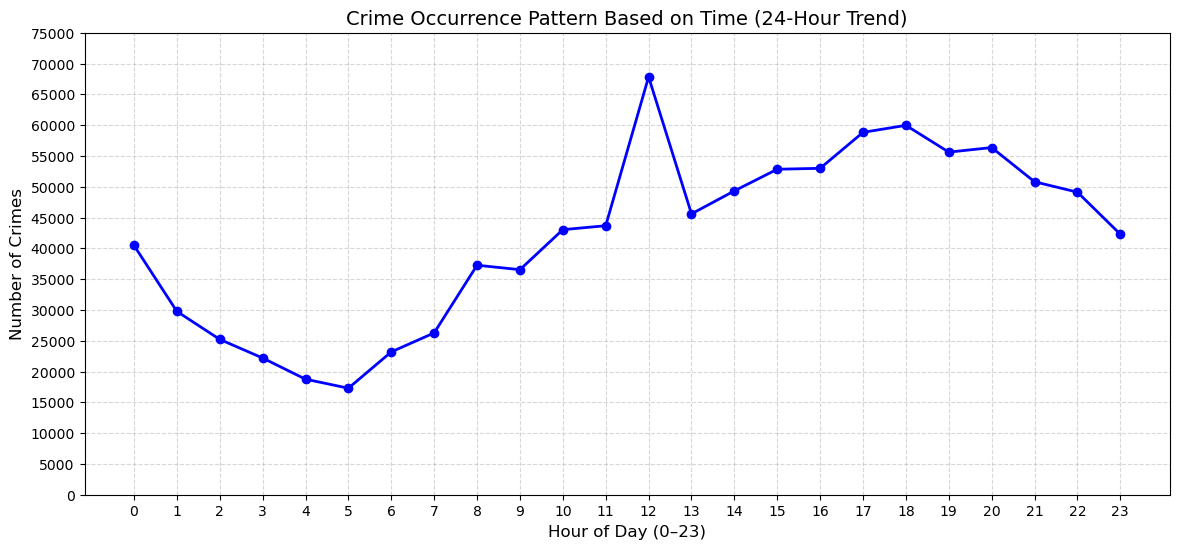

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
   ct.index,
    ct.values,
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title('Crime Occurrence Pattern Based on Time (24-Hour Trend)', fontsize=14)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)

plt.xticks(range(0,24))
plt.yticks(range(0,75001,5000))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Time vs Type of Crime

In [30]:
import seaborn as sns

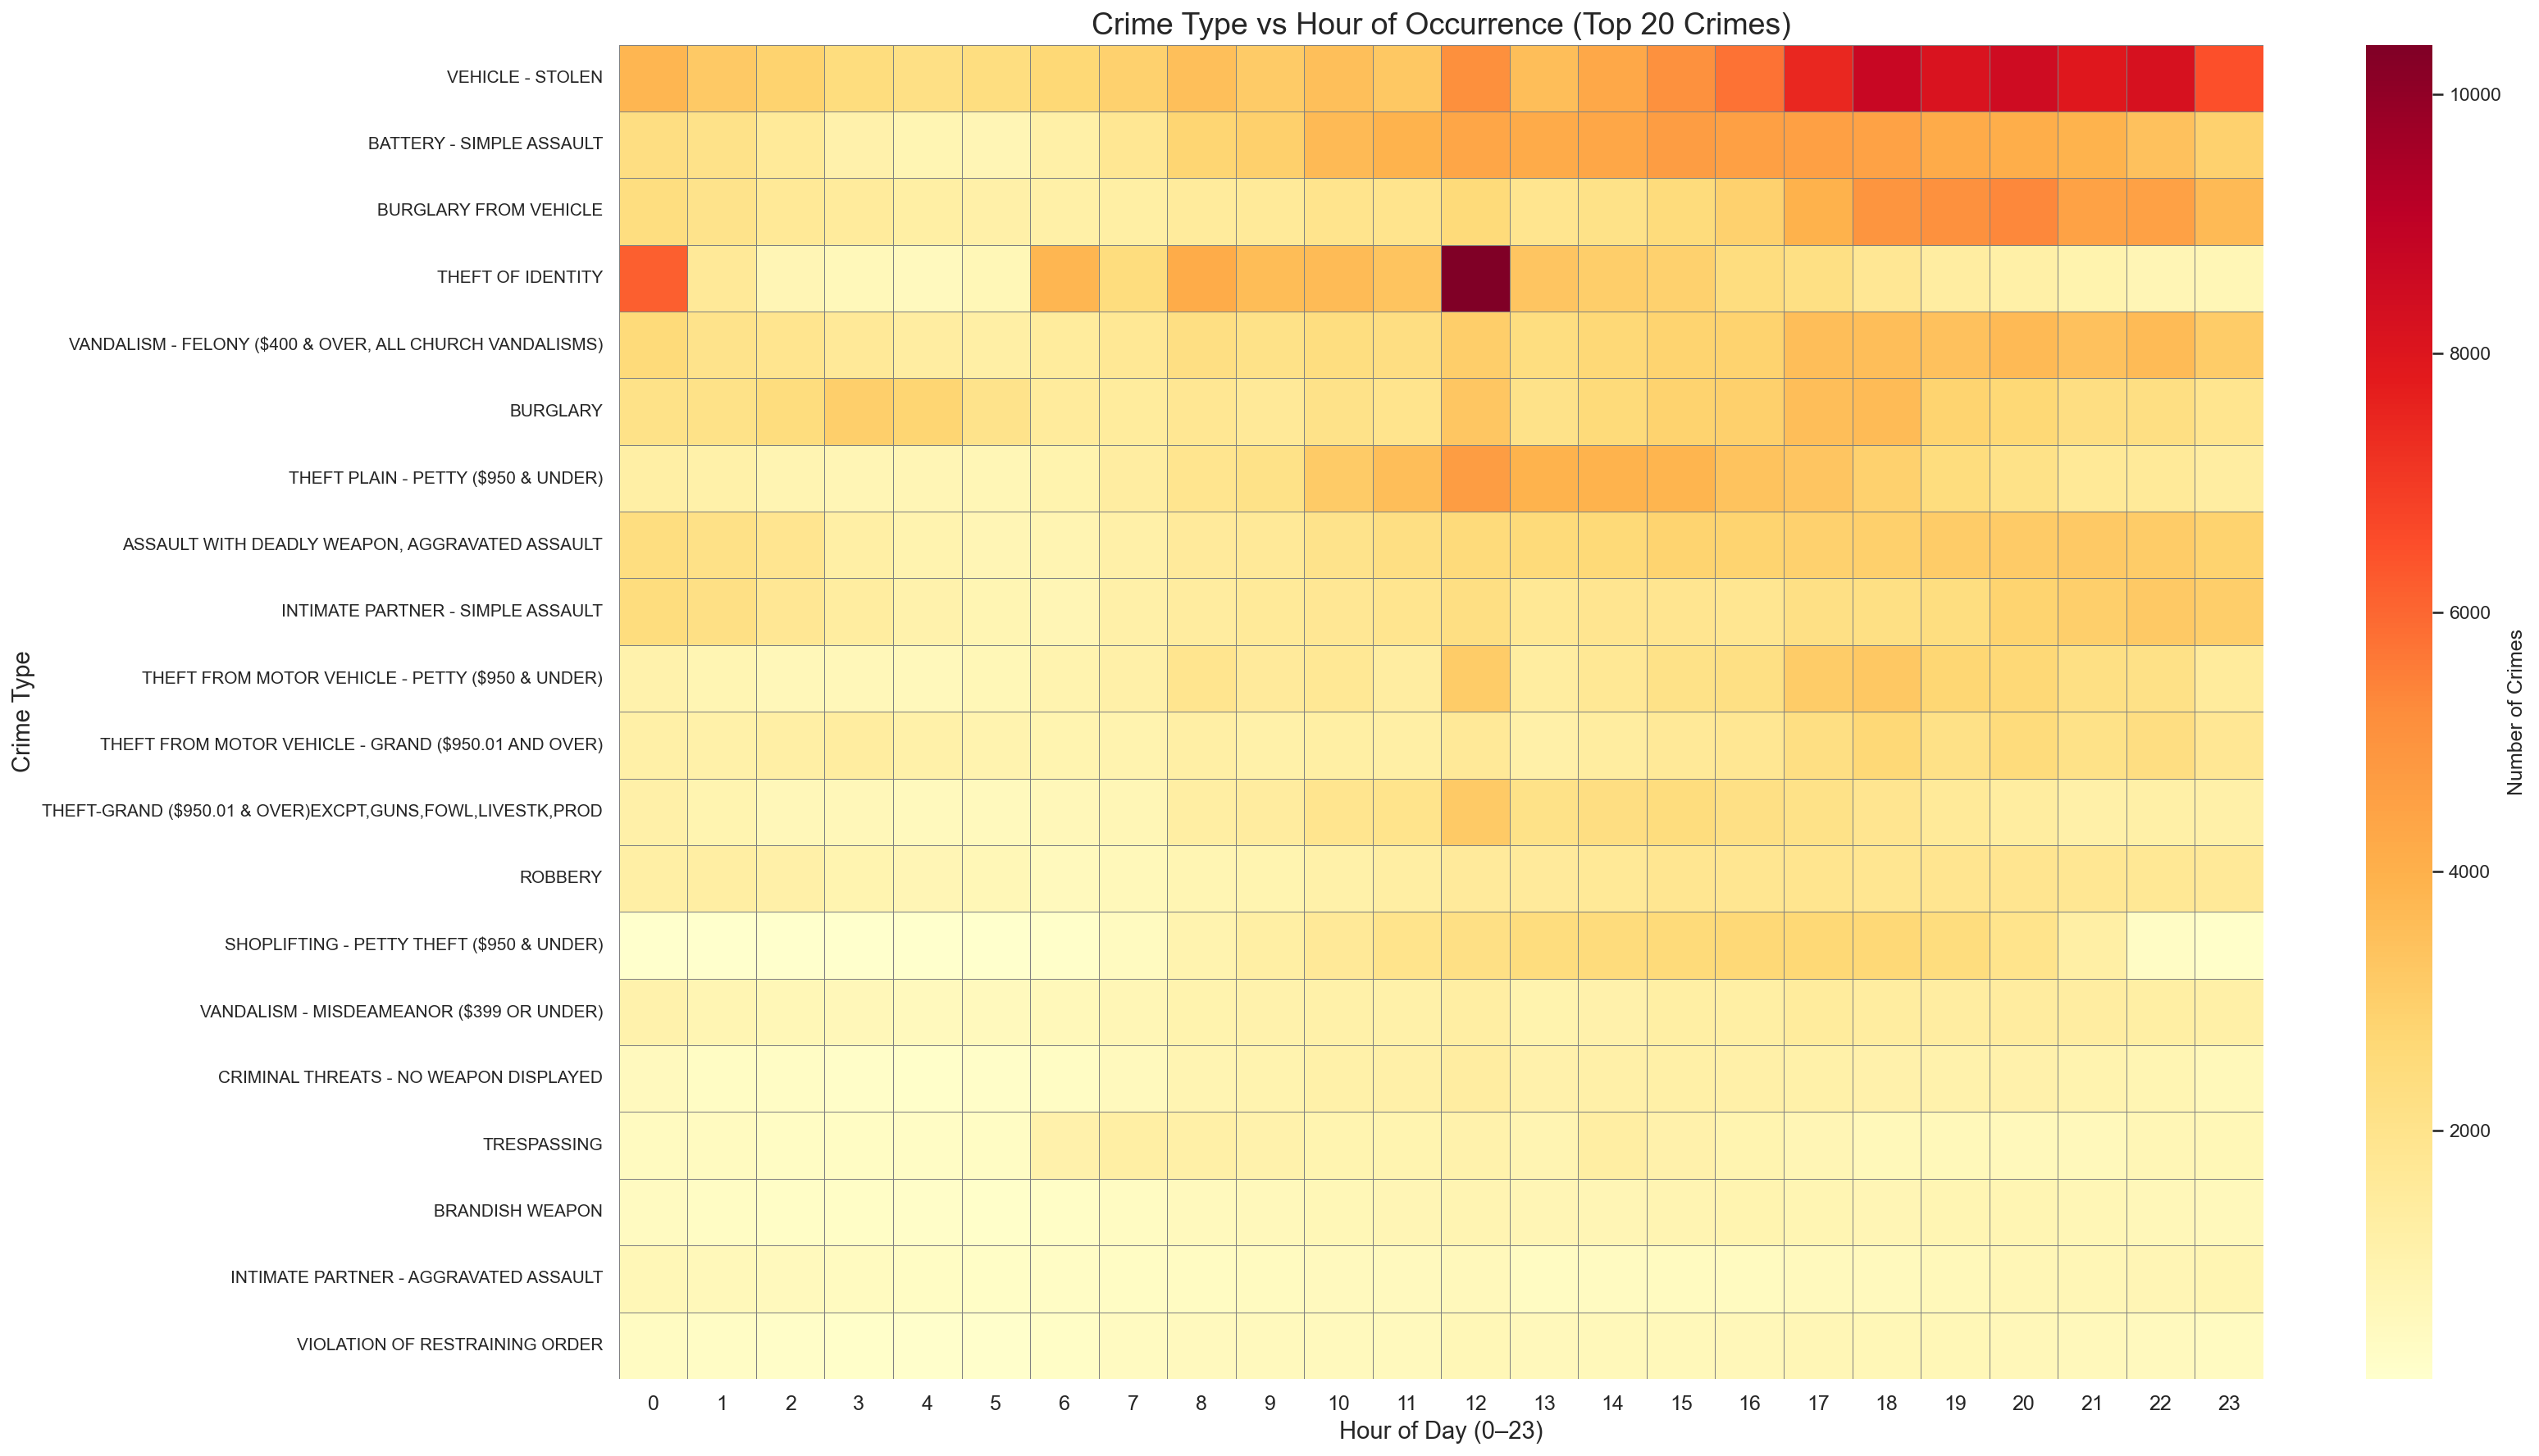

In [31]:
# Step 1: Create frequency table
ct = df1.groupby(['Crm Cd Desc', 'Hour']).size().unstack(fill_value=0)

# Step 2: Keep only TOP 20 crimes (VERY IMPORTANT for clarity)
top_crimes = ct.sum(axis=1).sort_values(ascending=False).head(20)
crime_time_top = ct.loc[top_crimes.index]

# Step 3: Set better style
sns.set(style="white")
plt.figure(figsize=(22, 12), dpi=150)

# Step 4: Heatmap with better visibility
sns.heatmap(
    crime_time_top,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Number of Crimes'},
    annot=False
)

# Step 5: Labels formatting
plt.title("Crime Type vs Hour of Occurrence (Top 20 Crimes)", fontsize=18)
plt.xlabel("Hour of Day (0–23)", fontsize=14)
plt.ylabel("Crime Type", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Area vs Type of Crime

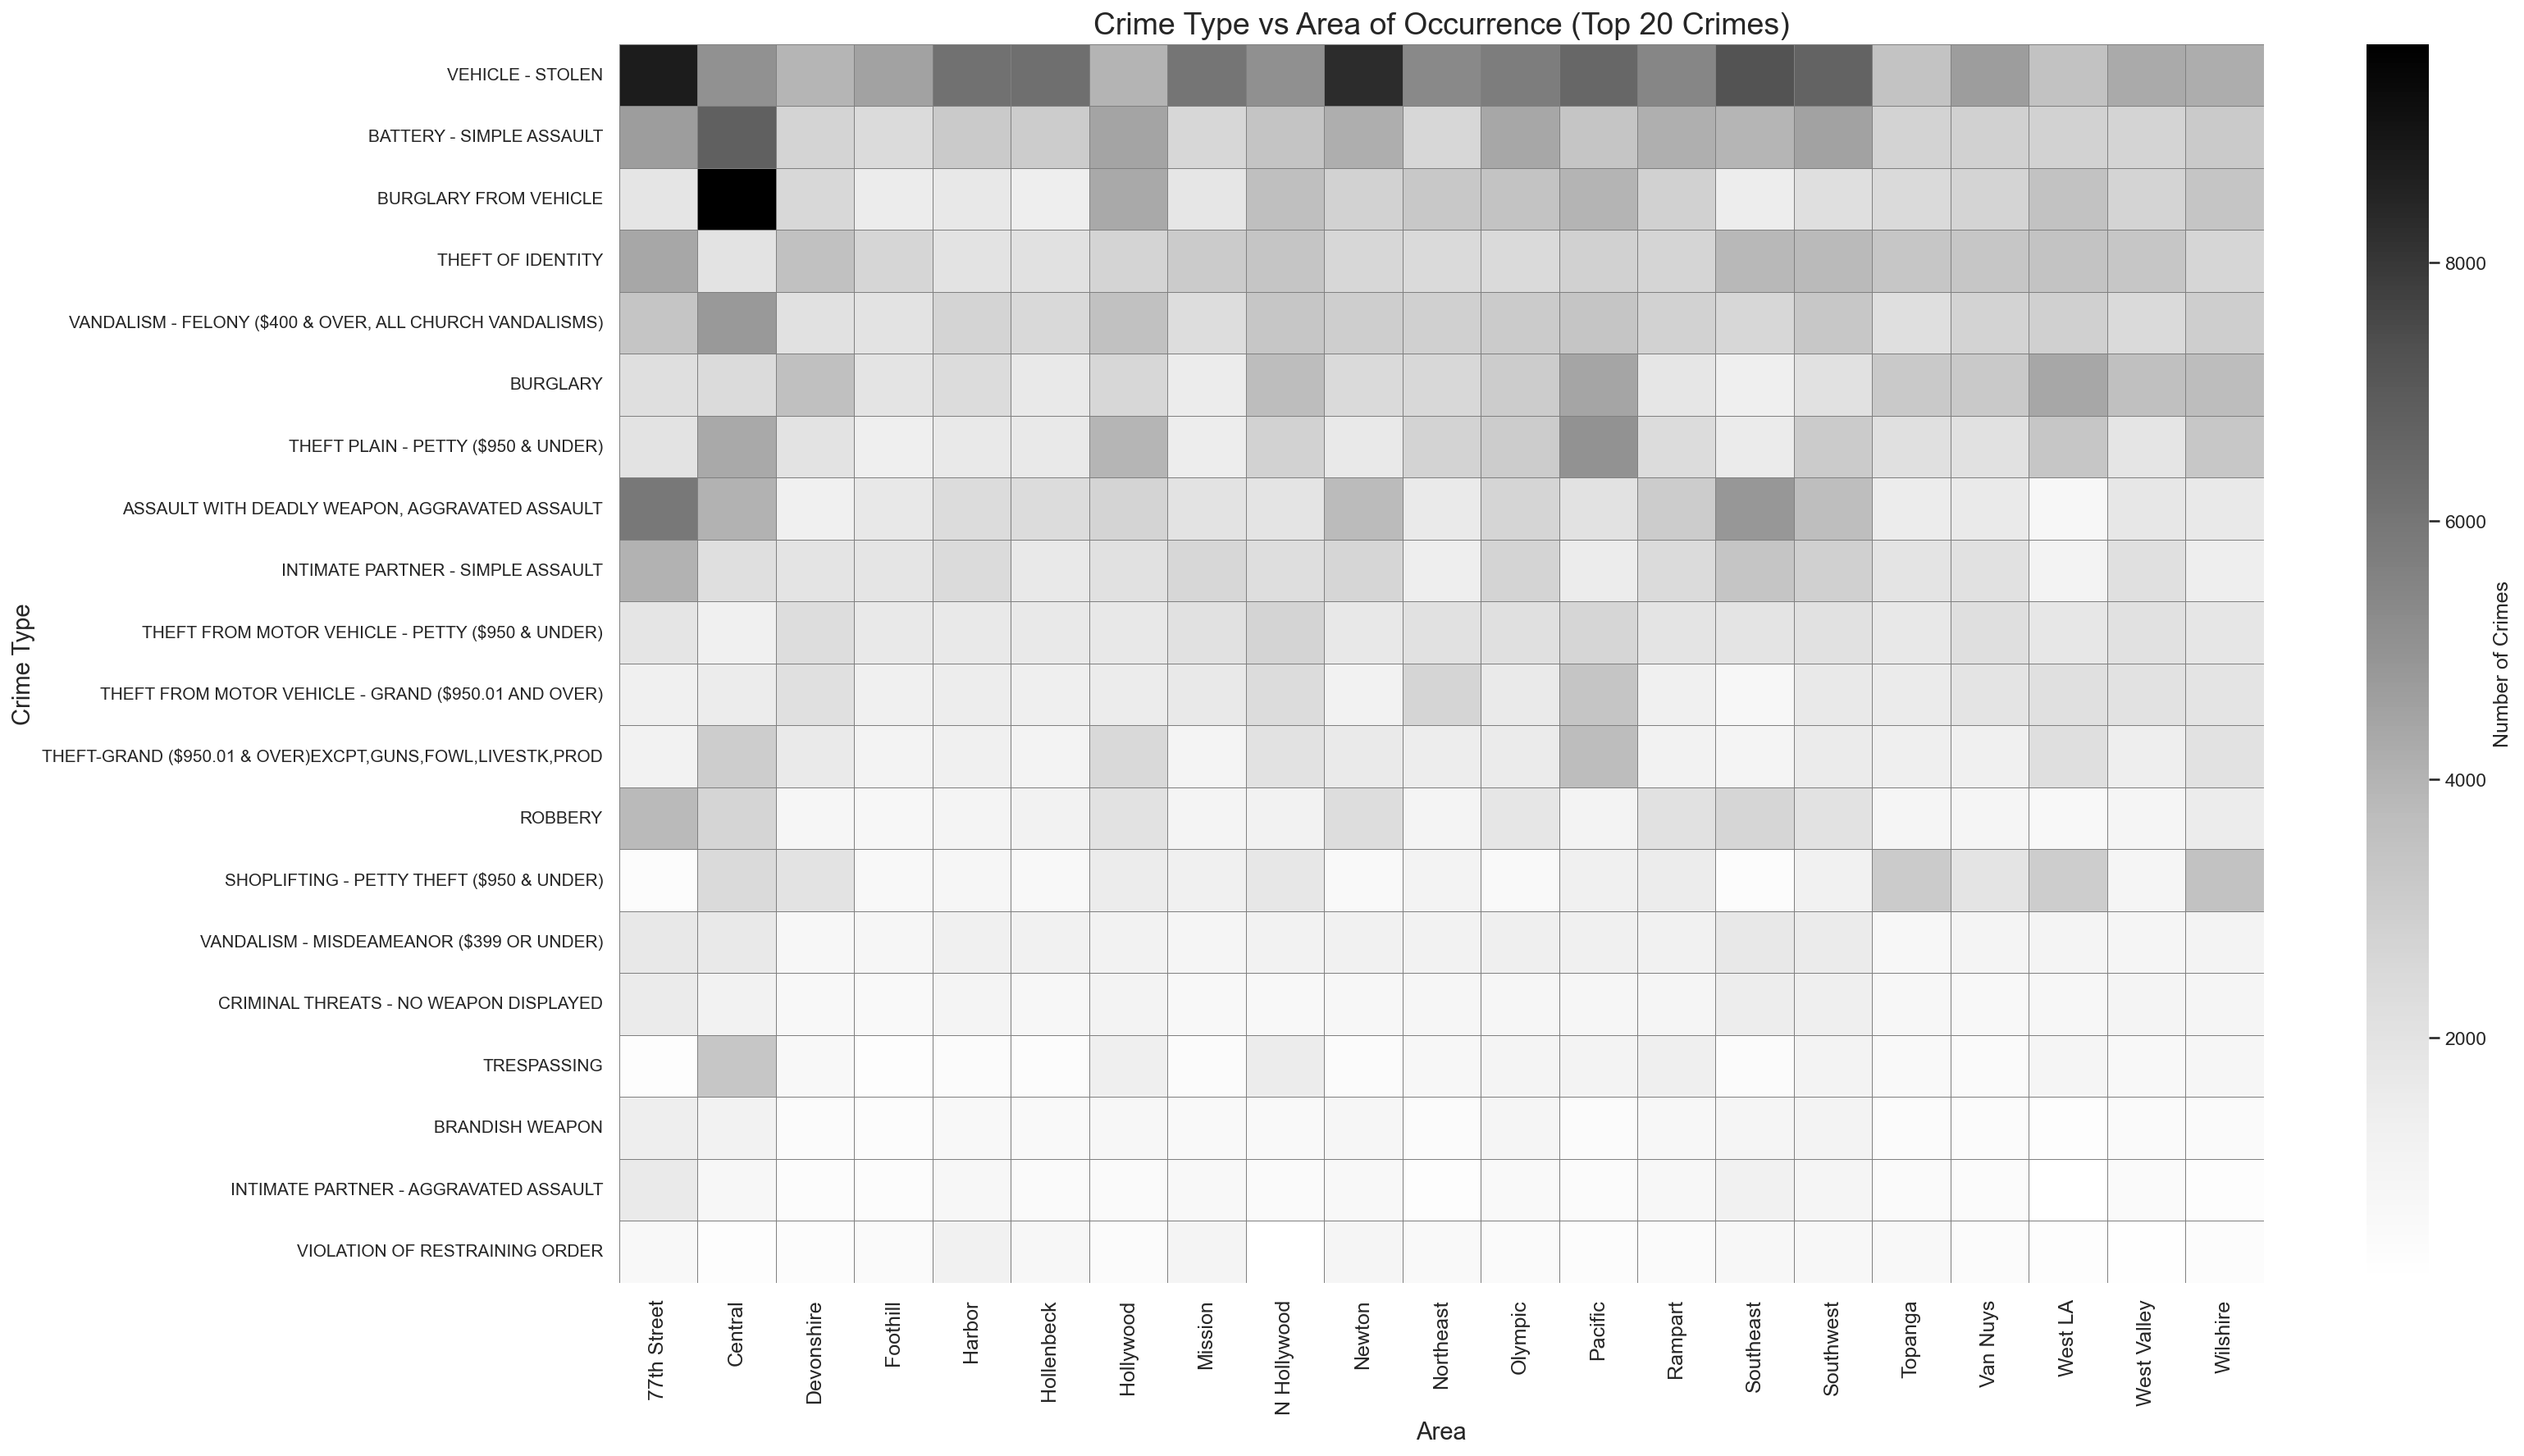

In [32]:
# Step 1: Create frequency table
ca = df1.groupby(['Crm Cd Desc', 'AREA NAME']).size().unstack(fill_value=0)

# Step 2: Keep only TOP 20 crimes (VERY IMPORTANT for clarity)
top_crimes = ca.sum(axis=1).sort_values(ascending=False).head(20)
crime_area_top = ca.loc[top_crimes.index]

# Step 3: Set better style
sns.set(style="white")
plt.figure(figsize=(22, 12), dpi=150)

# Step 4: Heatmap with better visibility
sns.heatmap(
    crime_area_top,
    cmap="Greys",
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Number of Crimes'},
    annot=False
)

# Step 5: Labels formatting
plt.title("Crime Type vs Area of Occurrence (Top 20 Crimes)", fontsize=18)
plt.xlabel("Area", fontsize=14)
plt.ylabel("Crime Type", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Area vs Count of Crime

In [33]:
# Count crimes in each area
area_crime_count = df1['AREA NAME'].value_counts()
print(area_crime_count)

AREA NAME
Central        69674
77th Street    61763
Pacific        59520
Southwest      57511
Hollywood      52430
N Hollywood    51107
Olympic        50071
Southeast      49941
Newton         49181
Wilshire       48240
Rampart        46826
West LA        45731
Northeast      42962
Van Nuys       42883
West Valley    42158
Devonshire     41766
Harbor         41462
Topanga        41376
Mission        40365
Hollenbeck     37095
Foothill       33136
Name: count, dtype: int64


In [34]:
area_crime_df = area_crime_count.reset_index()
area_crime_df.columns = ['Area', 'Crime Count']
print(area_crime_df.head())

          Area  Crime Count
0      Central        69674
1  77th Street        61763
2      Pacific        59520
3    Southwest        57511
4    Hollywood        52430


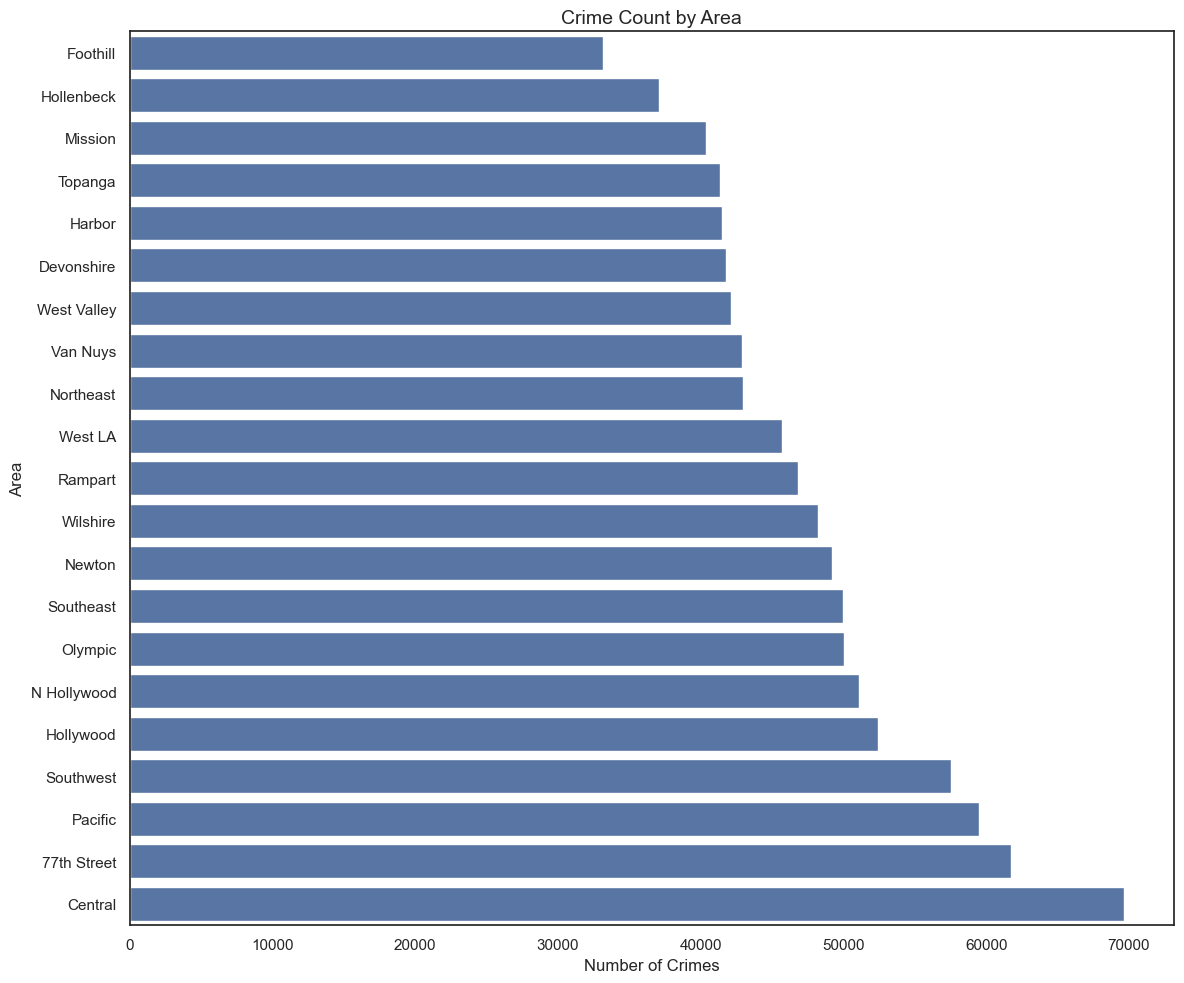

In [35]:
area_crime_df = area_crime_df.sort_values(
    by='Crime Count',
    ascending=True
)

plt.figure(figsize=(12,10))

sns.barplot(
    x='Crime Count',
    y='Area',
    data=area_crime_df
)

plt.title('Crime Count by Area', fontsize=14)
plt.xlabel('Number of Crimes')
plt.ylabel('Area')
#
plt.tight_layout()
plt.show()

# Time-Area vs Count of Crime

In [36]:
area_time = df1.groupby(['AREA NAME', 'Hour']).size().unstack(fill_value=0)
print(area_time.head())

Hour           0     1     2     3     4     5     6     7     8     9   ...  \
AREA NAME                                                                ...   
77th Street  2692  1992  1644  1486  1220  1118  1685  1758  2364  2214  ...   
Central      2668  2376  1875  1437  1216  1245  1926  2181  2631  2576  ...   
Devonshire   1442  1024   973   924   753   667   862  1006  1775  1420  ...   
Foothill     1202   955   824   735   654   585   829   883  1237  1217  ...   
Harbor       1852  1231  1033  1002   783   722  1001  1100  1478  1488  ...   

Hour           14    15    16    17    18    19    20    21    22    23  
AREA NAME                                                                
77th Street  2840  3068  3027  3417  3479  3298  3410  3264  3109  2710  
Central      3426  3637  3415  3697  4188  3990  3835  3407  3493  3280  
Devonshire   2179  2321  2341  2573  2595  2371  2337  2159  1723  1530  
Foothill     1555  1668  1741  1926  1970  1778  1887  1619  1699  13

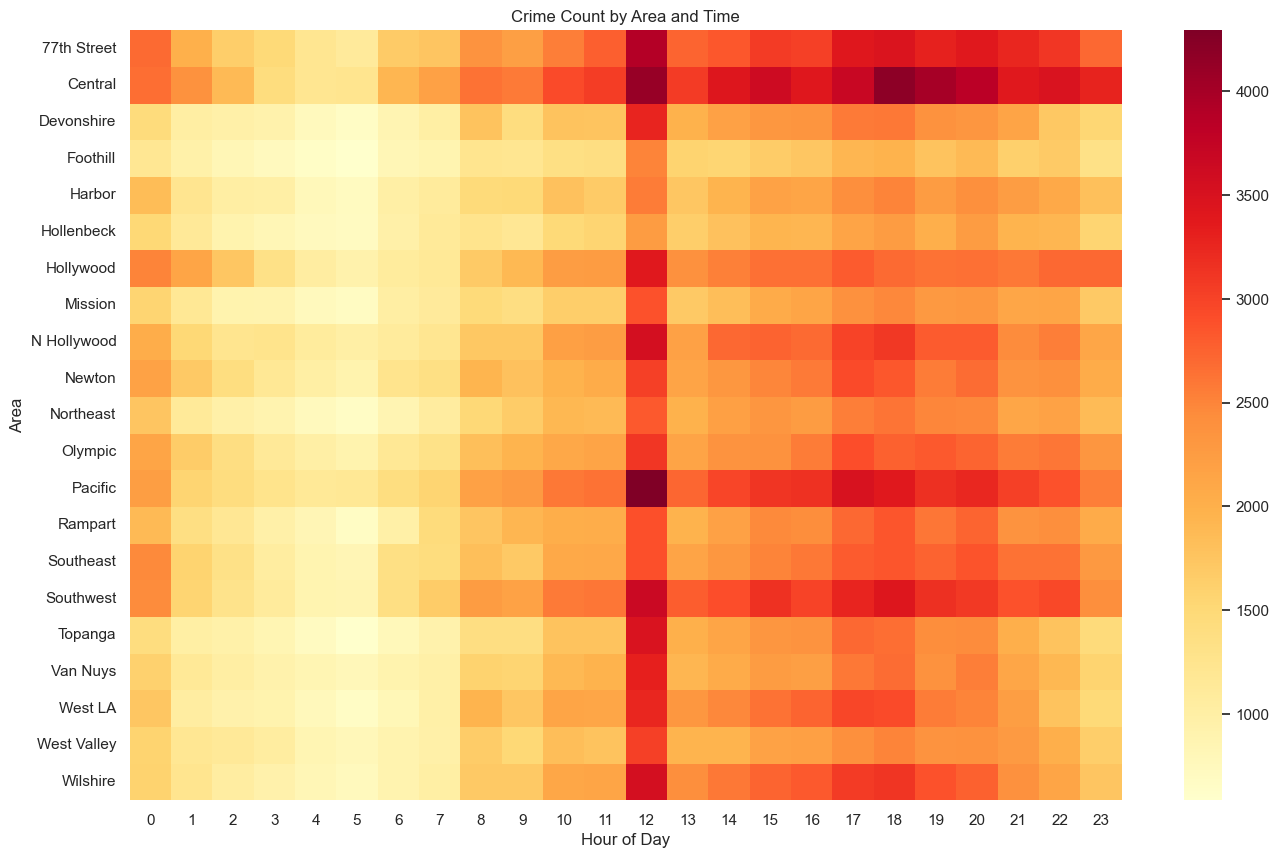

In [37]:
plt.figure(figsize=(16,10))

sns.heatmap(
    area_time,
    cmap='YlOrRd'
)

plt.title('Crime Count by Area and Time')
plt.xlabel('Hour of Day')
plt.ylabel('Area')

plt.show()

# Victim Age vs Count of Crimes

In [38]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 100]
labels = ['0-10', '11-20', '21-30', '31-40',
          '41-50', '51-60', '61-70', '71+']

df1['Age Group'] = pd.cut(
    df1['Vict Age'],
    bins=bins,
    labels=labels
)

age_crime = df1['Age Group'].value_counts().sort_index()
print(age_crime)

Age Group
0-10       5286
11-20     48340
21-30    190140
31-40    457964
41-50    126870
51-60     93657
61-70     54737
71+       28067
Name: count, dtype: int64


# Victim age vs Type of Crime & Count of Crime

In [39]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 100]

labels = ['0-10', '11-20', '21-30', '31-40',
          '41-50', '51-60', '61-70', '71+']

df1['Age Group'] = pd.cut(
    df1['Vict Age'],
    bins=bins,
    labels=labels
)

top_crimes = df1['Crm Cd Desc'].value_counts().head(15).index

age_crime_type = (
    df1[df1['Crm Cd Desc'].isin(top_crimes)]
    .groupby(['Age Group', 'Crm Cd Desc'])
    .size()
    .unstack(fill_value=0)
)

C:\Users\91801\AppData\Local\Temp\ipykernel_8928\2360239765.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age Group', 'Crm Cd Desc'])


In [40]:
df1.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Premis Desc,Status Desc,Hour,Age Group
0,190326475,03/01/20,03/01/20,21:30,7,Wilshire,784,510,VEHICLE - STOLEN,39,M,STREET,Adult Arrest,21,31-40
1,200106753,02/09/20,02/08/20,18:00,1,Central,182,330,BURGLARY FROM VEHICLE,47,M,BUS STOP/LAYOVER (ALSO QUERY 124),Invest Cont,18,41-50
2,200320258,11/11/20,11/04/20,17:00,3,Southwest,356,480,BIKE - STOLEN,19,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",Invest Cont,17,11-20
3,200907217,05/10/23,03/10/20,20:37,9,Van Nuys,964,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,CLOTHING STORE,Invest Cont,20,11-20
4,200412582,09/09/20,09/09/20,06:30,4,Hollenbeck,413,510,VEHICLE - STOLEN,39,M,STREET,Invest Cont,6,31-40


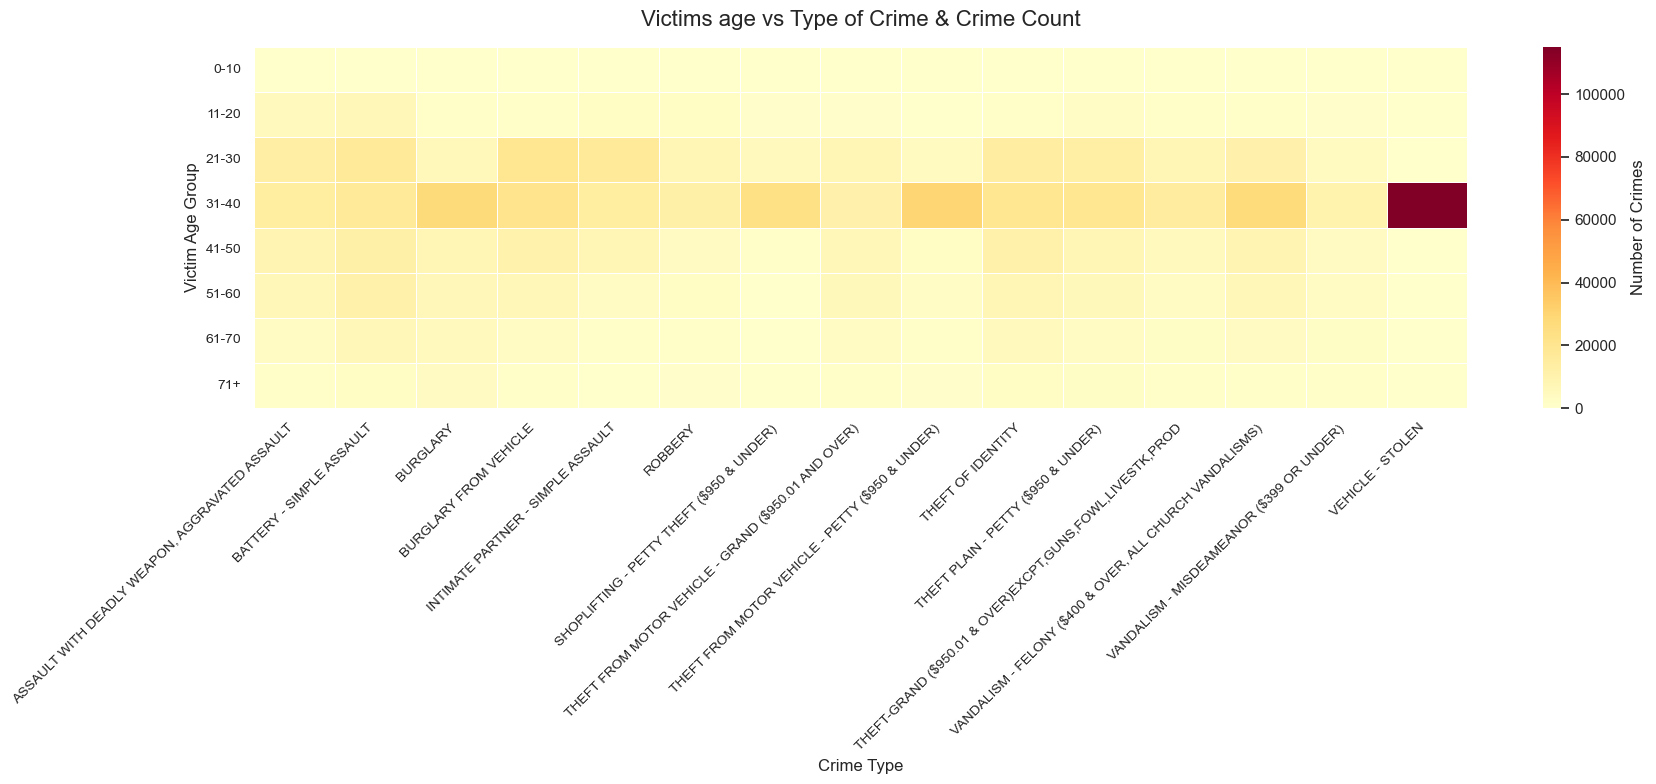

In [41]:
plt.figure(figsize=(18,8))

sns.heatmap(
    age_crime_type,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Number of Crimes'}
)

plt.title(
    "Victims age vs Type of Crime & Crime Count",
    fontsize=16,
    pad=15
)

plt.xlabel("Crime Type", fontsize=12)
plt.ylabel("Victim Age Group", fontsize=12)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()
plt.show()

# Connecting the Database to Notebook

In [42]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [43]:
from sqlalchemy import create_engine
username = "postgres"
passowrd = "030822"
host = "localhost"
port = "5432"
database = "crime_records"

engine = create_engine(f"postgresql+psycopg2://{username}:{passowrd}@{host}:{port}/{database}")

# Loading the clean dataset into PostgreSQL database

In [44]:
table_name = "crime_data"
df1.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data has been successfully loaded into the table '{table_name}' in database '{database}'.")

Data has been successfully loaded into the table 'crime_data' in database 'crime_records'.


# Loading the acctual dataset to PostGreSQL Database

In [45]:
table_name = "crime_data_actual"
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data has been successfully loaded into the table '{table_name}' in database '{database}'.")

Data has been successfully loaded into the table 'crime_data_actual' in database 'crime_records'.
